In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import time
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from flax import nnx

In [11]:
import jax
print(jax.devices())
print(jax.device_count())

[CudaDevice(id=0)]
1


In [5]:
from google.colab import drive
drive.mount('/content/drive')

print("listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
listo


In [6]:
dataset_path = '/content/drive/MyDrive/Computacion paralela y distribuida/Tarea2_JeanRabbat/Wonders of World/Wonders of World'

IMG_SIZE = 224

images_list = []
labels_list = []
class_names = sorted(os.listdir(dataset_path))
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    for img_file in os.listdir(class_path):
        if img_file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(class_path, img_file)
            images_list.append(img_path)
            labels_list.append(class_to_idx[class_name])

X_temp, X_test, y_temp, y_test = train_test_split(
    images_list, labels_list, test_size=0.15, random_state=42, stratify=labels_list
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

def load_and_preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

Train: 2693 | Val: 576 | Test: 577


In [7]:
class CNNModel(nnx.Module):
    def __init__(self, rngs):
        self.conv1 = nnx.Conv(3, 32, kernel_size=(3, 3), rngs=rngs)
        self.conv2 = nnx.Conv(32, 64, kernel_size=(3, 3), rngs=rngs)
        self.dense = nnx.Linear(64 * 56 * 56, 128, rngs=rngs)
        self.output = nnx.Linear(128, 10, rngs=rngs)

    def __call__(self, x):
        x = self.conv1(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = self.conv2(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = self.dense(x)
        x = nnx.relu(x)
        x = self.output(x)
        return x

class CNNModelSmall(nnx.Module):
    def __init__(self, rngs):
        self.conv1 = nnx.Conv(3, 16, kernel_size=(3, 3), rngs=rngs)
        self.conv2 = nnx.Conv(16, 32, kernel_size=(3, 3), rngs=rngs)
        self.dense = nnx.Linear(32 * 56 * 56, 64, rngs=rngs)
        self.output = nnx.Linear(64, 10, rngs=rngs)

    def __call__(self, x):
        x = self.conv1(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = self.conv2(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = self.dense(x)
        x = nnx.relu(x)
        x = self.output(x)
        return x

class CNNModelLarge(nnx.Module):
    def __init__(self, rngs):
        self.conv1 = nnx.Conv(3, 64, kernel_size=(3, 3), rngs=rngs)
        self.conv2 = nnx.Conv(64, 128, kernel_size=(3, 3), rngs=rngs)
        self.dense = nnx.Linear(128 * 56 * 56, 256, rngs=rngs)
        self.output = nnx.Linear(256, 10, rngs=rngs)

    def __call__(self, x):
        x = self.conv1(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = self.conv2(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = self.dense(x)
        x = nnx.relu(x)
        x = self.output(x)
        return x


In [8]:
def create_batch_generator_fixed(image_paths, labels, batch_size, shuffle=True):
    indices = np.arange(len(image_paths))
    if shuffle:
        np.random.shuffle(indices)

    batches = []
    for i in range(0, len(image_paths), batch_size):
        batch_indices = indices[i:i+batch_size]
        batch_images = np.array([load_and_preprocess_image(image_paths[idx]) for idx in batch_indices])
        batch_labels = np.array([labels[idx] for idx in batch_indices])
        batches.append((batch_images, batch_labels))

    return batches

def loss_fn(model, x, y):
    logits = model(x)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()
    return loss

def compute_accuracy(model, batches):
    correct = 0
    total = 0
    for x_batch, y_batch in batches:
        logits = model(x_batch)
        predictions = jnp.argmax(logits, axis=1)
        correct += jnp.sum(predictions == y_batch)
        total += len(y_batch)
    return float(correct) / total

def train_model(model_class, batch_size, learning_rate, num_epochs=3):
    train_batches = create_batch_generator_fixed(X_train, y_train, batch_size)
    val_batches = create_batch_generator_fixed(X_val, y_val, batch_size, shuffle=False)
    test_batches = create_batch_generator_fixed(X_test, y_test, batch_size, shuffle=False)

    rngs = nnx.Rngs(0)
    model = model_class(rngs=rngs)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(nnx.state(model))

    metrics = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'test_acc': [],
        'epoch_times': []
    }

    time_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        epoch_loss = 0.0

        for x_batch, y_batch in train_batches:
            loss, grads = nnx.value_and_grad(loss_fn)(model, x_batch, y_batch)
            grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1.0, 1.0), grads)
            updates, opt_state = optimizer.update(grads, opt_state)

            model.conv1.kernel = optax.apply_updates(model.conv1.kernel, updates.conv1.kernel)
            model.conv1.bias = optax.apply_updates(model.conv1.bias, updates.conv1.bias)
            model.conv2.kernel = optax.apply_updates(model.conv2.kernel, updates.conv2.kernel)
            model.conv2.bias = optax.apply_updates(model.conv2.bias, updates.conv2.bias)
            model.dense.kernel = optax.apply_updates(model.dense.kernel, updates.dense.kernel)
            model.dense.bias = optax.apply_updates(model.dense.bias, updates.dense.bias)
            model.output.kernel = optax.apply_updates(model.output.kernel, updates.output.kernel)
            model.output.bias = optax.apply_updates(model.output.bias, updates.output.bias)

            epoch_loss += loss

        epoch_loss /= len(train_batches)
        train_acc = compute_accuracy(model, train_batches)
        val_acc = compute_accuracy(model, val_batches)
        test_acc = compute_accuracy(model, test_batches)

        epoch_time = time.time() - epoch_start

        metrics['train_loss'].append(float(epoch_loss))
        metrics['train_acc'].append(train_acc)
        metrics['val_acc'].append(val_acc)
        metrics['test_acc'].append(test_acc)
        metrics['epoch_times'].append(epoch_time)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    total_time = time.time() - time_start
    avg_time = total_time / num_epochs
    throughput = (len(X_train) * num_epochs) / total_time

    metrics['total_time'] = total_time
    metrics['avg_time'] = avg_time
    metrics['throughput'] = throughput
    metrics['final_test_acc'] = metrics['test_acc'][-1]
    metrics['final_val_acc'] = metrics['val_acc'][-1]
    metrics['final_loss'] = metrics['train_loss'][-1]

    return model, metrics

def train_model_with_dtype(model_class, batch_size, learning_rate, dtype_name, num_epochs=3):
    train_batches_orig = create_batch_generator_fixed(X_train, y_train, batch_size)
    val_batches_orig = create_batch_generator_fixed(X_val, y_val, batch_size, shuffle=False)
    test_batches_orig = create_batch_generator_fixed(X_test, y_test, batch_size, shuffle=False)

    if dtype_name == 'float32':
        dtype = jnp.float32
    elif dtype_name == 'float16':
        dtype = jnp.float16
    else:
        dtype = jnp.bfloat16

    train_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in train_batches_orig]
    val_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in val_batches_orig]
    test_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in test_batches_orig]

    rngs = nnx.Rngs(0)
    model = model_class(rngs=rngs)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(nnx.state(model))

    metrics = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'test_acc': [],
        'epoch_times': []
    }

    time_start = time.time()

    try:
        for epoch in range(num_epochs):
            epoch_start = time.time()
            epoch_loss = 0.0

            for x_batch, y_batch in train_batches:
                loss, grads = nnx.value_and_grad(loss_fn)(model, x_batch, y_batch)
                grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1.0, 1.0), grads)
                updates, opt_state = optimizer.update(grads, opt_state)

                model.conv1.kernel = optax.apply_updates(model.conv1.kernel, updates.conv1.kernel)
                model.conv1.bias = optax.apply_updates(model.conv1.bias, updates.conv1.bias)
                model.conv2.kernel = optax.apply_updates(model.conv2.kernel, updates.conv2.kernel)
                model.conv2.bias = optax.apply_updates(model.conv2.bias, updates.conv2.bias)
                model.dense.kernel = optax.apply_updates(model.dense.kernel, updates.dense.kernel)
                model.dense.bias = optax.apply_updates(model.dense.bias, updates.dense.bias)
                model.output.kernel = optax.apply_updates(model.output.kernel, updates.output.kernel)
                model.output.bias = optax.apply_updates(model.output.bias, updates.output.bias)

                epoch_loss += loss

            epoch_loss /= len(train_batches)
            train_acc = compute_accuracy(model, train_batches)
            val_acc = compute_accuracy(model, val_batches)
            test_acc = compute_accuracy(model, test_batches)

            epoch_time = time.time() - epoch_start

            metrics['train_loss'].append(float(epoch_loss))
            metrics['train_acc'].append(train_acc)
            metrics['val_acc'].append(val_acc)
            metrics['test_acc'].append(test_acc)
            metrics['epoch_times'].append(epoch_time)

            print(f"{dtype_name} | Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    except Exception as e:
        print(f"Error con {dtype_name}: {str(e)}")
        metrics['error'] = str(e)

    total_time = time.time() - time_start
    avg_time = total_time / num_epochs if num_epochs > 0 else 0
    throughput = (len(X_train) * num_epochs) / total_time if total_time > 0 else 0

    metrics['total_time'] = total_time
    metrics['avg_time'] = avg_time
    metrics['throughput'] = throughput
    metrics['final_test_acc'] = metrics['test_acc'][-1] if metrics['test_acc'] else 0
    metrics['final_val_acc'] = metrics['val_acc'][-1] if metrics['val_acc'] else 0
    metrics['final_loss'] = metrics['train_loss'][-1] if metrics['train_loss'] else 0

    return model, metrics



EXPERIMENTO 1: Impacto del tamaño de lote

Batch Size: 32
Epoch 1/3 | Loss: nan | Train: 0.4152 | Val: 0.3281 | Test: 0.3778
Epoch 2/3 | Loss: nan | Train: 0.2726 | Val: 0.2396 | Test: 0.2426
Epoch 3/3 | Loss: nan | Train: 0.5381 | Val: 0.4115 | Test: 0.4610

Batch Size: 64
Epoch 1/3 | Loss: nan | Train: 0.2191 | Val: 0.1944 | Test: 0.2062
Epoch 2/3 | Loss: nan | Train: 0.2592 | Val: 0.2500 | Test: 0.2409
Epoch 3/3 | Loss: nan | Train: 0.4092 | Val: 0.3646 | Test: 0.3605

Batch Size: 128
Epoch 1/3 | Loss: nan | Train: 0.1292 | Val: 0.1146 | Test: 0.1179
Epoch 2/3 | Loss: nan | Train: 0.3212 | Val: 0.2778 | Test: 0.2981
Epoch 3/3 | Loss: nan | Train: 0.1203 | Val: 0.1094 | Test: 0.1161

EXPERIMENTO 2: Impacto de la tasa de aprendizaje

Learning Rate: 0.01
Epoch 1/3 | Loss: nan | Train: 0.1017 | Val: 0.1007 | Test: 0.1005
Epoch 2/3 | Loss: nan | Train: 0.1411 | Val: 0.1337 | Test: 0.1231
Epoch 3/3 | Loss: nan | Train: 0.1021 | Val: 0.1024 | Test: 0.1023

Learning Rate: 0.001
Epoch 1/3 |

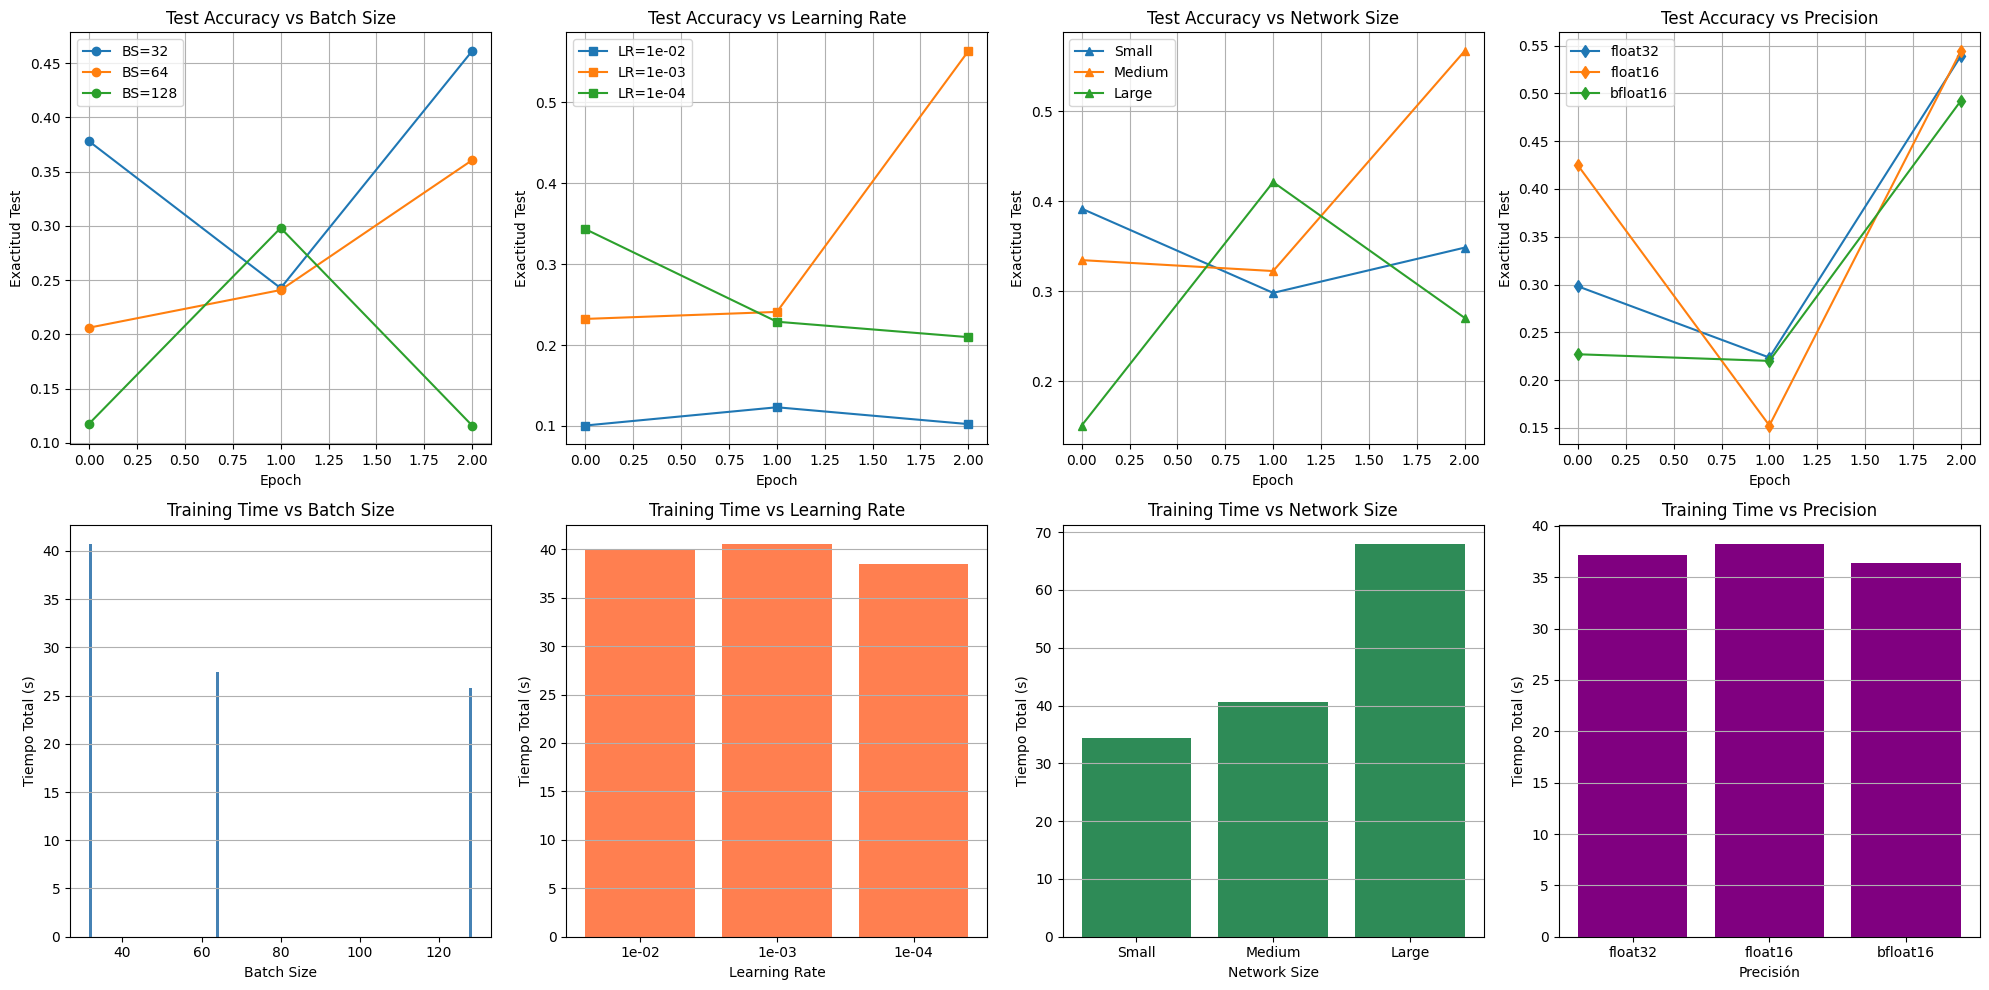


RESUMEN DE RESULTADOS

Mejor Batch Size: 32 (Exactitud: 0.4610)
Mejor Learning Rate: 0.001 (Exactitud: 0.5633)
Mejor Tamaño de Red: Medium (Exactitud: 0.5667)
Mejor Precisión: float16 (Exactitud: 0.5442)

TODOS LOS EXPERIMENTOS COMPLETADOS EXITOSAMENTE


In [10]:
print("\n" + "="*80)
print("EXPERIMENTO 1: Impacto del tamaño de lote")
print("="*80)

batch_sizes = [32, 64, 128]
results_batch = {}

for bs in batch_sizes:
    print(f"\nBatch Size: {bs}")
    model, metrics = train_model(CNNModel, batch_size=bs, learning_rate=1e-3, num_epochs=3)
    results_batch[bs] = metrics

print("\n" + "="*80)
print("EXPERIMENTO 2: Impacto de la tasa de aprendizaje")
print("="*80)

learning_rates = [1e-2, 1e-3, 1e-4]
results_lr = {}

for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    model, metrics = train_model(CNNModel, batch_size=32, learning_rate=lr, num_epochs=3)
    results_lr[lr] = metrics

print("\n" + "="*80)
print("EXPERIMENTO 3: Impacto del tamaño de la red")
print("="*80)

network_configs = [("Small", CNNModelSmall), ("Medium", CNNModel), ("Large", CNNModelLarge)]
results_network = {}

for name, model_class in network_configs:
    print(f"\nTamaño de red: {name}")
    model, metrics = train_model(model_class, batch_size=32, learning_rate=1e-3, num_epochs=3)
    results_network[name] = metrics

print("\n" + "="*80)
print("EXPERIMENTO 4: Análisis de Precisión Numérica")
print("="*80)

def train_model_with_dtype(model_class, batch_size, learning_rate, dtype_name, num_epochs=3):
    train_batches_orig = create_batch_generator_fixed(X_train, y_train, batch_size)
    val_batches_orig = create_batch_generator_fixed(X_val, y_val, batch_size, shuffle=False)
    test_batches_orig = create_batch_generator_fixed(X_test, y_test, batch_size, shuffle=False)

    if dtype_name == 'float32':
        dtype = jnp.float32
    elif dtype_name == 'float16':
        dtype = jnp.float16
    else:
        dtype = jnp.bfloat16

    train_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in train_batches_orig]
    val_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in val_batches_orig]
    test_batches = [(jnp.asarray(x, dtype=dtype), y) for x, y in test_batches_orig]

    rngs = nnx.Rngs(0)
    model = model_class(rngs=rngs)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(nnx.state(model))

    metrics = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'test_acc': [],
        'epoch_times': []
    }

    time_start = time.time()

    try:
        for epoch in range(num_epochs):
            epoch_start = time.time()
            epoch_loss = 0.0

            for x_batch, y_batch in train_batches:
                loss, grads = nnx.value_and_grad(loss_fn)(model, x_batch, y_batch)
                grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1.0, 1.0), grads)
                updates, opt_state = optimizer.update(grads, opt_state)

                model.conv1.kernel = optax.apply_updates(model.conv1.kernel, updates.conv1.kernel)
                model.conv1.bias = optax.apply_updates(model.conv1.bias, updates.conv1.bias)
                model.conv2.kernel = optax.apply_updates(model.conv2.kernel, updates.conv2.kernel)
                model.conv2.bias = optax.apply_updates(model.conv2.bias, updates.conv2.bias)
                model.dense.kernel = optax.apply_updates(model.dense.kernel, updates.dense.kernel)
                model.dense.bias = optax.apply_updates(model.dense.bias, updates.dense.bias)
                model.output.kernel = optax.apply_updates(model.output.kernel, updates.output.kernel)
                model.output.bias = optax.apply_updates(model.output.bias, updates.output.bias)

                epoch_loss += loss

            epoch_loss /= len(train_batches)
            train_acc = compute_accuracy(model, train_batches)
            val_acc = compute_accuracy(model, val_batches)
            test_acc = compute_accuracy(model, test_batches)

            epoch_time = time.time() - epoch_start

            metrics['train_loss'].append(float(epoch_loss))
            metrics['train_acc'].append(train_acc)
            metrics['val_acc'].append(val_acc)
            metrics['test_acc'].append(test_acc)
            metrics['epoch_times'].append(epoch_time)

            print(f"{dtype_name} | Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    except Exception as e:
        print(f"Error con {dtype_name}: {str(e)}")
        metrics['error'] = str(e)

    total_time = time.time() - time_start
    avg_time = total_time / num_epochs if num_epochs > 0 else 0
    throughput = (len(X_train) * num_epochs) / total_time if total_time > 0 else 0

    metrics['total_time'] = total_time
    metrics['avg_time'] = avg_time
    metrics['throughput'] = throughput
    metrics['final_test_acc'] = metrics['test_acc'][-1] if metrics['test_acc'] else 0
    metrics['final_val_acc'] = metrics['val_acc'][-1] if metrics['val_acc'] else 0
    metrics['final_loss'] = metrics['train_loss'][-1] if metrics['train_loss'] else 0

    return model, metrics

precision_dtypes = ['float32', 'float16', 'bfloat16']
results_precision = {}

for dtype_name in precision_dtypes:
    print(f"\nPrecisión: {dtype_name}")
    model, metrics = train_model_with_dtype(CNNModel, batch_size=32, learning_rate=1e-3, dtype_name=dtype_name, num_epochs=3)
    results_precision[dtype_name] = metrics

print("\n" + "="*80)
print("TABLA 1: Impacto del tamaño de lote")
print("="*80)

df_batch = pd.DataFrame({
    'Batch Size': list(results_batch.keys()),
    'Exactitud Test': [results_batch[bs]['final_test_acc'] for bs in results_batch],
    'Exactitud Val': [results_batch[bs]['final_val_acc'] for bs in results_batch],
    'Pérdida Final': [results_batch[bs]['final_loss'] for bs in results_batch],
    'Tiempo Total (s)': [results_batch[bs]['total_time'] for bs in results_batch],
    'Tiempo Promedio (s)': [results_batch[bs]['avg_time'] for bs in results_batch],
    'Throughput (img/s)': [results_batch[bs]['throughput'] for bs in results_batch]
})

print(df_batch.to_string(index=False))

print("\n" + "="*80)
print("TABLA 2: Impacto de la tasa de aprendizaje")
print("="*80)

df_lr = pd.DataFrame({
    'Learning Rate': [f'{lr:.0e}' for lr in results_lr.keys()],
    'Exactitud Test': [results_lr[lr]['final_test_acc'] for lr in results_lr],
    'Exactitud Val': [results_lr[lr]['final_val_acc'] for lr in results_lr],
    'Pérdida Final': [results_lr[lr]['final_loss'] for lr in results_lr],
    'Tiempo Total (s)': [results_lr[lr]['total_time'] for lr in results_lr],
    'Throughput (img/s)': [results_lr[lr]['throughput'] for lr in results_lr]
})

print(df_lr.to_string(index=False))

print("\n" + "="*80)
print("TABLA 3: Impacto del tamaño de la red")
print("="*80)

df_network = pd.DataFrame({
    'Tamaño Red': list(results_network.keys()),
    'Exactitud Test': [results_network[name]['final_test_acc'] for name in results_network],
    'Exactitud Val': [results_network[name]['final_val_acc'] for name in results_network],
    'Pérdida Final': [results_network[name]['final_loss'] for name in results_network],
    'Tiempo Total (s)': [results_network[name]['total_time'] for name in results_network],
    'Throughput (img/s)': [results_network[name]['throughput'] for name in results_network]
})

print(df_network.to_string(index=False))

print("\n" + "="*80)
print("TABLA 4: Análisis de Precisión Numérica")
print("="*80)

df_precision = pd.DataFrame({
    'Precisión': list(results_precision.keys()),
    'Exactitud Test': [results_precision[dtype]['final_test_acc'] for dtype in results_precision],
    'Exactitud Val': [results_precision[dtype]['final_val_acc'] for dtype in results_precision],
    'Pérdida Final': [results_precision[dtype]['final_loss'] for dtype in results_precision],
    'Tiempo Total (s)': [results_precision[dtype]['total_time'] for dtype in results_precision],
    'Throughput (img/s)': [results_precision[dtype]['throughput'] for dtype in results_precision]
})

print(df_precision.to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

ax = axes[0, 0]
for bs in results_batch:
    ax.plot(results_batch[bs]['test_acc'], marker='o', label=f'BS={bs}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Exactitud Test')
ax.set_title('Test Accuracy vs Batch Size')
ax.legend()
ax.grid()

ax = axes[0, 1]
for lr in results_lr:
    ax.plot(results_lr[lr]['test_acc'], marker='s', label=f'LR={lr:.0e}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Exactitud Test')
ax.set_title('Test Accuracy vs Learning Rate')
ax.legend()
ax.grid()

ax = axes[0, 2]
for name in results_network:
    ax.plot(results_network[name]['test_acc'], marker='^', label=f'{name}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Exactitud Test')
ax.set_title('Test Accuracy vs Network Size')
ax.legend()
ax.grid()

ax = axes[0, 3]
for dtype in results_precision:
    ax.plot(results_precision[dtype]['test_acc'], marker='d', label=f'{dtype}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Exactitud Test')
ax.set_title('Test Accuracy vs Precision')
ax.legend()
ax.grid()

ax = axes[1, 0]
ax.bar(list(results_batch.keys()), [results_batch[bs]['total_time'] for bs in results_batch], color='steelblue')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Tiempo Total (s)')
ax.set_title('Training Time vs Batch Size')
ax.grid(axis='y')

ax = axes[1, 1]
ax.bar([f'{lr:.0e}' for lr in results_lr.keys()], [results_lr[lr]['total_time'] for lr in results_lr], color='coral')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Tiempo Total (s)')
ax.set_title('Training Time vs Learning Rate')
ax.grid(axis='y')

ax = axes[1, 2]
ax.bar(list(results_network.keys()), [results_network[name]['total_time'] for name in results_network], color='seagreen')
ax.set_xlabel('Network Size')
ax.set_ylabel('Tiempo Total (s)')
ax.set_title('Training Time vs Network Size')
ax.grid(axis='y')

ax = axes[1, 3]
ax.bar(list(results_precision.keys()), [results_precision[dtype]['total_time'] for dtype in results_precision], color='purple')
ax.set_xlabel('Precisión')
ax.set_ylabel('Tiempo Total (s)')
ax.set_title('Training Time vs Precision')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('experimentos_completos.png', dpi=100, bbox_inches='tight')
print("\nGráficos guardados como 'experimentos_completos.png'")
plt.show()

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS")
print("="*80)

best_batch = max(results_batch, key=lambda x: results_batch[x]['final_test_acc'])
best_lr = max(results_lr, key=lambda x: results_lr[x]['final_test_acc'])
best_network = max(results_network, key=lambda x: results_network[x]['final_test_acc'])
best_precision = max(results_precision, key=lambda x: results_precision[x]['final_test_acc'])

print(f"\nMejor Batch Size: {best_batch} (Exactitud: {results_batch[best_batch]['final_test_acc']:.4f})")
print(f"Mejor Learning Rate: {best_lr} (Exactitud: {results_lr[best_lr]['final_test_acc']:.4f})")
print(f"Mejor Tamaño de Red: {best_network} (Exactitud: {results_network[best_network]['final_test_acc']:.4f})")
print(f"Mejor Precisión: {best_precision} (Exactitud: {results_precision[best_precision]['final_test_acc']:.4f})")

print("\n" + "="*80)
print("TODOS LOS EXPERIMENTOS COMPLETADOS EXITOSAMENTE")
print("="*80)